**Dependency note:** this notebook needs kernel state from **`09_Hub_Ablation_Validation`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 09.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/09_state.pkl")
print("Restored checkpoint: checkpoints/09_state.pkl")

Comparison with regular pairwise graphs (Hypergraph vs Graphs)

In [ ]:
# ============================================================
# GRAPH vs HYPERGRAPH COMPARISON
# ============================================================
# Experiments A, B, C from reviewer feedback
#
# EXPERIMENT A: Standard graph vs hypergraph ablation
#   Build ordinary pairwise graph from neuron proximity
#   Compute standard centrality metrics
#   Run same hub ablation
#   Compare: does graph predict same vulnerabilities?
#
# EXPERIMENT B: Predictive power comparison
#   For each neuron predict seizure recruitment
#   Graph features: degree, betweenness, PageRank, eigenvector
#   Hypergraph features: hyperdegree, tensor centrality,
#                        spectral features, co-occurrence weight
#   Compare: which predicts better?
#
# EXPERIMENT C: Territory emergence
#   Does ordinary graph recover routing/propagation/modulation?
#   Does hypergraph recover all three?
#   Compare explanatory power
# ============================================================

import numpy as np
import scipy.sparse as sp
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, pearsonr
from scipy.sparse.linalg import eigsh
import networkx as nx
import time

print("GRAPH vs HYPERGRAPH COMPARISON")
print("="*55)

# ── Build standard pairwise graph ────────────────────────────
print("\nBuilding standard pairwise proximity graph...")
print("(nodes=interneurons, edges=pairs within 15μm)")

inter_coords_g = np.array([
    [patch.loc[n]['x'],
     patch.loc[n]['y'],
     patch.loc[n]['z']]
    for n in all_nodes])
inter_tree_g = cKDTree(inter_coords_g)

# Pairwise edges: interneurons within 15μm of each other
pairs = inter_tree_g.query_pairs(r=15000)
print(f"  Pairwise edges found: {len(pairs):,}")

# Build NetworkX graph with attributes
G_standard = nx.Graph()
for i, node in enumerate(all_nodes):
    G_standard.add_node(i,
        layer=layer_labels[i],
        hyperdegree=node_degree[node],
        tensor_c=tensor_centrality[i],
        co_weight=co_occurrence_weight[i])

for i, j in pairs:
    dist = np.linalg.norm(
        inter_coords_g[i] - inter_coords_g[j])
    G_standard.add_edge(i, j,
                         weight=1.0/(dist+1e-6))

print(f"  Graph nodes: {G_standard.number_of_nodes()}")
print(f"  Graph edges: {G_standard.number_of_edges()}")
print(f"  Mean degree: {np.mean([d for _,d in G_standard.degree()]):.1f}")

# ── Compute standard graph metrics ───────────────────────────
print("\nComputing standard graph centrality metrics...")

# Degree centrality
degree_c = nx.degree_centrality(G_standard)
degree_arr = np.array([degree_c[i]
                        for i in range(n_nodes)])

# Eigenvector centrality
print("  Eigenvector centrality...", end=' ', flush=True)
try:
    eigen_c = nx.eigenvector_centrality_numpy(
        G_standard, weight='weight')
    eigen_arr = np.array([eigen_c[i]
                           for i in range(n_nodes)])
except Exception:
    eigen_arr = degree_arr.copy()
print("done")

# PageRank
print("  PageRank...", end=' ', flush=True)
pagerank_c = nx.pagerank(G_standard, weight='weight')
pagerank_arr = np.array([pagerank_c[i]
                          for i in range(n_nodes)])
print("done")

# Betweenness centrality (sample for speed)
print("  Betweenness (sampled)...", end=' ', flush=True)
between_c = nx.betweenness_centrality(
    G_standard, k=min(100, n_nodes),
    weight='weight', normalized=True)
between_arr = np.array([between_c[i]
                         for i in range(n_nodes)])
print("done")

# Graph spectral gap
print("  Graph Laplacian spectral gap...",
      end=' ', flush=True)
L_graph = nx.normalized_laplacian_matrix(
    G_standard, weight='weight').astype(float)
evals_g = eigsh(L_graph, k=6, which='SM',
                return_eigenvectors=False)
evals_g = np.sort(np.real(evals_g))
gap_graph = float(evals_g[1] - evals_g[0])
print(f"done (gap={gap_graph:.4f})")

print(f"\nGraph metrics computed:")
print(f"  Degree centrality range: "
      f"[{degree_arr.min():.4f}, {degree_arr.max():.4f}]")
print(f"  Eigenvector range: "
      f"[{eigen_arr.min():.4f}, {eigen_arr.max():.4f}]")
print(f"  PageRank range: "
      f"[{pagerank_arr.min():.4f}, {pagerank_arr.max():.4f}]")
print(f"  Betweenness range: "
      f"[{between_arr.min():.4f}, {between_arr.max():.4f}]")
print(f"  Graph spectral gap: {gap_graph:.6f}")
print(f"  Hypergraph spectral gap: {gap_intact:.6f}")

# ── EXPERIMENT A: Graph vs Hypergraph ablation ────────────────
print(f"\n{'='*55}")
print(f"EXPERIMENT A: Hub Ablation Comparison")
print(f"{'='*55}")

# Graph hub ranking: by eigenvector centrality
graph_hub_ranking = np.argsort(eigen_arr)[::-1]
# Hypergraph hub ranking: by tensor centrality (already computed)
hyper_hub_ranking = np.argsort(tensor_centrality)[::-1]

# Check overlap between graph and hypergraph hubs
for pct in [0.01, 0.05, 0.10]:
    n_hubs = max(1, int(n_nodes * pct))
    graph_hubs = set(graph_hub_ranking[:n_hubs])
    hyper_hubs = set(hyper_hub_ranking[:n_hubs])
    overlap = len(graph_hubs & hyper_hubs)
    print(f"  Top {pct*100:.0f}% hub overlap "
          f"(graph vs hypergraph): "
          f"{overlap}/{n_hubs} "
          f"({overlap/n_hubs*100:.1f}%)")

# Run ablation using GRAPH hubs
print(f"\nRunning graph-hub ablation...")
graph_ablation_results = {}

for abl_name, abl_frac in [
        ('Intact', 0.00), ('Top 1%', 0.01),
        ('Top 5%', 0.05), ('Top 10%', 0.10)]:

    if abl_frac == 0:
        graph_ablation_results[abl_name] = {
            'pct_recruited': 100.0,
            'spread_time':   ablation_results[
                'Intact']['spread_time'],
            'gap_ratio':     1.0,
            'tc_ratio':      1.0
        }
        continue

    n_abl    = max(1, int(n_nodes * abl_frac))
    ablated_g = graph_hub_ranking[:n_abl]

    # Rebuild Laplacian
    L_abl_g, rem_mask_g, rem_idx_g = \
        ablate_and_rebuild_laplacian(
            ablated_g, C_w)
    gap_abl_g = compute_spectral_gap(L_abl_g)

    # Territory clarity
    tc_abl_g, _ = compute_territory_clarity(
        rem_idx_g, cent_pyr, cent_int,
        layer_labels_arr)

    # PDE
    pde_g = run_ablated_seizure(
        rem_mask_g, rem_idx_g,
        K_diff_final, excitability_field,
        layer_labels_arr)

    graph_ablation_results[abl_name] = {
        'pct_recruited': pde_g['pct_recruited']
                          if pde_g else np.nan,
        'spread_time':   pde_g['spread_time']
                          if pde_g else np.nan,
        'gap_ratio':     gap_abl_g/gap_intact,
        'tc_ratio':      tc_abl_g/tc_intact
    }

    print(f"  Graph {abl_name}: "
          f"recruited={graph_ablation_results[abl_name]['pct_recruited']:.1f}% "
          f"spread={graph_ablation_results[abl_name]['spread_time']:.2f} "
          f"gap_ratio={graph_ablation_results[abl_name]['gap_ratio']:.4f}")

# Compare
print(f"\nAblation comparison (Graph vs Hypergraph):")
print(f"  {'Level':>8} {'G-Recruit':>12} "
      f"{'H-Recruit':>12} {'G-Spread':>10} "
      f"{'H-Spread':>10}")
for abl_name in ['Intact','Top 1%',
                  'Top 5%','Top 10%']:
    gr = graph_ablation_results.get(abl_name, {})
    hr = ablation_results.get(abl_name, {})
    print(f"  {abl_name:>8} "
          f"{gr.get('pct_recruited',100):>12.1f} "
          f"{hr.get('pct_recruited',100):>12.1f} "
          f"{gr.get('spread_time',0):>10.2f} "
          f"{hr.get('spread_time',0):>10.2f}")

# ── EXPERIMENT B: Predictive power ───────────────────────────
print(f"\n{'='*55}")
print(f"EXPERIMENT B: Predictive Power Comparison")
print(f"{'='*55}")
print("Predicting seizure recruitment from graph vs "
      "hypergraph features...")

# Ground truth: recruitment time from best scenario
fi_truth = results_final['Distributed']['first_ictal']
recruited_truth = ~np.isnan(fi_truth)

# Binary prediction: recruited (1) or not (0)
# Use top X% of each metric as positive prediction
y_true = recruited_truth.astype(int)

# Since almost all neurons are recruited (100%)
# use RECRUITMENT TIME as the prediction target
# Lower time = more important = better predicted by
# high centrality
y_time = fi_truth.copy()
y_time[np.isnan(y_time)] = fi_truth[
    ~np.isnan(fi_truth)].max() + 10

# Standard graph features
graph_features = {
    'Degree':       degree_arr,
    'Eigenvector':  eigen_arr,
    'PageRank':     pagerank_arr,
    'Betweenness':  between_arr,
}

# Hypergraph features
hyper_features = {
    'Hyperdegree':      np.array([node_degree[n]
                         for n in all_nodes],
                         dtype=float),
    'Tensor centrality': tensor_centrality,
    'Co-occurrence wt':  co_occurrence_weight,
    'Mode 1 (routing)':  np.abs(U[:, 0]),
    'Mode 2 (prop)':     np.abs(U[:, 1]),
}

print(f"\n  Predicting recruitment TIME "
      f"(Spearman r with 1/time):")
print(f"  {'Metric':30s} {'r':>8} {'p':>12} "
      f"{'Type':>12}")
print(f"  {'-'*66}")

predictive_results = {}

# Graph features — lower time = earlier fire
# high centrality should predict EARLY recruitment
# so we use -time as target (high = early)
target = -y_time   # high = recruited early

for fname, fvals in graph_features.items():
    r, p = spearmanr(fvals, target)
    predictive_results[f'G:{fname}'] = abs(r)
    sig = '***' if p<0.001 else '**' if p<0.01 \
          else '*' if p<0.05 else 'ns'
    print(f"  {'G: '+fname:30s} "
          f"{r:>+8.4f} {p:>12.2e} "
          f"{'GRAPH':>12} {sig}")

for fname, fvals in hyper_features.items():
    r, p = spearmanr(fvals, target)
    predictive_results[f'H:{fname}'] = abs(r)
    sig = '***' if p<0.001 else '**' if p<0.01 \
          else '*' if p<0.05 else 'ns'
    print(f"  {'H: '+fname:30s} "
          f"{r:>+8.4f} {p:>12.2e} "
          f"{'HYPERGRAPH':>12} {sig}")

# Best graph vs best hypergraph
best_graph = max(
    {k: v for k, v in predictive_results.items()
     if k.startswith('G:')}.items(),
    key=lambda x: x[1])
best_hyper = max(
    {k: v for k, v in predictive_results.items()
     if k.startswith('H:')}.items(),
    key=lambda x: x[1])

print(f"\n  Best graph predictor:      "
      f"{best_graph[0]} (|r|={best_graph[1]:.4f})")
print(f"  Best hypergraph predictor: "
      f"{best_hyper[0]} (|r|={best_hyper[1]:.4f})")
print(f"  Hypergraph advantage: "
      f"{(best_hyper[1]-best_graph[1])/best_graph[1]*100:+.1f}%")

# ── EXPERIMENT C: Territory emergence ────────────────────────
print(f"\n{'='*55}")
print(f"EXPERIMENT C: Territory Emergence")
print(f"{'='*55}")
print("Can standard graph recover routing/propagation "
      "territories?")

# Graph-based territory assignment
# Use eigenvector centrality as routing proxy
# Use degree as propagation proxy
graph_routing    = (eigen_arr - eigen_arr.min()) / \
                   (eigen_arr.max() - eigen_arr.min())
graph_propagation = (degree_arr - degree_arr.min()) / \
                    (degree_arr.max() - degree_arr.min())
graph_territory  = graph_routing - graph_propagation

# Hypergraph territory
hyper_routing    = (cent_pyr - cent_pyr.min()) / \
                   (cent_pyr.max() - cent_pyr.min())
hyper_propagation = (cent_int - cent_int.min()) / \
                    (cent_int.max() - cent_int.min())
hyper_territory  = hyper_routing - hyper_propagation

# Territory clarity: |mean L4 - mean L2|
def territory_clarity_from_score(scores, ll):
    l4 = scores[ll=='Layer 4'].mean()
    l2 = scores[ll=='Layer 2'].mean()
    return abs(l4 - l2), l4, l2

g_clarity, g_l4, g_l2 = \
    territory_clarity_from_score(
        graph_territory, layer_labels_arr)
h_clarity, h_l4, h_l2 = \
    territory_clarity_from_score(
        hyper_territory, layer_labels_arr)

print(f"\n  Graph territory:")
print(f"    L4 mean routing score: {g_l4:+.4f}")
print(f"    L2 mean routing score: {g_l2:+.4f}")
print(f"    Territory clarity:     {g_clarity:.4f}")

print(f"\n  Hypergraph territory:")
print(f"    L4 mean routing score: {h_l4:+.4f}")
print(f"    L2 mean routing score: {h_l2:+.4f}")
print(f"    Territory clarity:     {h_clarity:.4f}")

print(f"\n  Hypergraph territory advantage: "
      f"{(h_clarity-g_clarity)/g_clarity*100:+.1f}%")

# Per-layer territory recovery comparison
print(f"\n  Per-layer territory recovery:")
print(f"  {'Layer':>10} {'Graph score':>14} "
      f"{'Hyper score':>14}")
print(f"  {'-'*42}")
for l in ['Layer 2','Layer 3',
           'Layer 4','Layer 5']:
    lm = layer_labels_arr == l
    if lm.sum() == 0:
        continue
    gs = graph_territory[lm].mean()
    hs = hyper_territory[lm].mean()
    print(f"  {l:>10} {gs:>+14.4f} {hs:>+14.4f}")

# Correlation between graph and hypergraph territories
r_terr, p_terr = spearmanr(
    graph_territory, hyper_territory)
print(f"\n  Graph vs Hypergraph territory correlation:")
print(f"  Spearman r = {r_terr:.4f}  p = {p_terr:.2e}")
print(f"  {'Territories agree' if r_terr>0.7 else 'Territories DISAGREE — hypergraph reveals additional structure'}")

# Modulation territory (Layer 3 astrocyte hub)
# Can graph recover this?
g_l3 = graph_territory[layer_labels_arr=='Layer 3'].mean()
h_l3 = hyper_territory[layer_labels_arr=='Layer 3'].mean()
print(f"\n  Layer 3 modulation territory:")
print(f"    Graph:      {g_l3:+.4f}")
print(f"    Hypergraph: {h_l3:+.4f}")
print(f"    {'Graph recovers L3 modulation' if abs(g_l3) > 0.05 else 'Graph MISSES L3 modulation territory'}")
print(f"    {'Hypergraph recovers L3 modulation' if abs(h_l3) > 0.05 else 'Hypergraph also misses L3 modulation'}")

# Summary statement
print(f"\n{'='*55}")
print(f"EXPERIMENT SUMMARY")
print(f"{'='*55}")
print(f"""
EXPERIMENT A (Ablation):
  Graph hub ablation vs Hypergraph hub ablation
  → Compare recruitment/spread changes above

EXPERIMENT B (Prediction):
  Best graph predictor:      {best_graph[0]} |r|={best_graph[1]:.4f}
  Best hypergraph predictor: {best_hyper[0]} |r|={best_hyper[1]:.4f}
  → {'Hypergraph OUTPERFORMS graph' if best_hyper[1] > best_graph[1] else 'Graph matches hypergraph'}

EXPERIMENT C (Territory):
  Graph clarity:      {g_clarity:.4f}
  Hypergraph clarity: {h_clarity:.4f}
  → {'Hypergraph reveals STRONGER territory separation' if h_clarity > g_clarity else 'Similar territory separation'}

STATEMENT SUPPORTED BY RESULTS:
  {'Hypergraph-defined routing hubs are disproportionately important for global communication, and this vulnerability cannot be fully explained by standard graph topology alone.' if best_hyper[1] > best_graph[1] and h_clarity > g_clarity else 'Both frameworks reveal similar structure — hypergraph provides richer representation but not strictly stronger prediction.'}
""")

GRAPH vs HYPERGRAPH COMPARISON

Building standard pairwise proximity graph...
(nodes=interneurons, edges=pairs within 15μm)
  Pairwise edges found: 23,028
  Graph nodes: 852
  Graph edges: 23028
  Mean degree: 54.1

Computing standard graph centrality metrics...
  Eigenvector centrality... done
  PageRank... done
  Betweenness (sampled)... done
  Graph Laplacian spectral gap... done (gap=0.0129)

Graph metrics computed:
  Degree centrality range: [0.0188, 0.1234]
  Eigenvector range: [0.0000, 0.1441]
  PageRank range: [0.0006, 0.0016]
  Betweenness range: [0.0000, 0.0715]
  Graph spectral gap: 0.012920
  Hypergraph spectral gap: 0.024030

EXPERIMENT A: Hub Ablation Comparison
  Top 1% hub overlap (graph vs hypergraph): 0/8 (0.0%)
  Top 5% hub overlap (graph vs hypergraph): 0/42 (0.0%)
  Top 10% hub overlap (graph vs hypergraph): 0/85 (0.0%)

Running graph-hub ablation...
  Graph Top 1%: recruited=99.8% spread=19.04 gap_ratio=1.2272
  Graph Top 5%: recruited=99.6% spread=29.06 gap_ratio

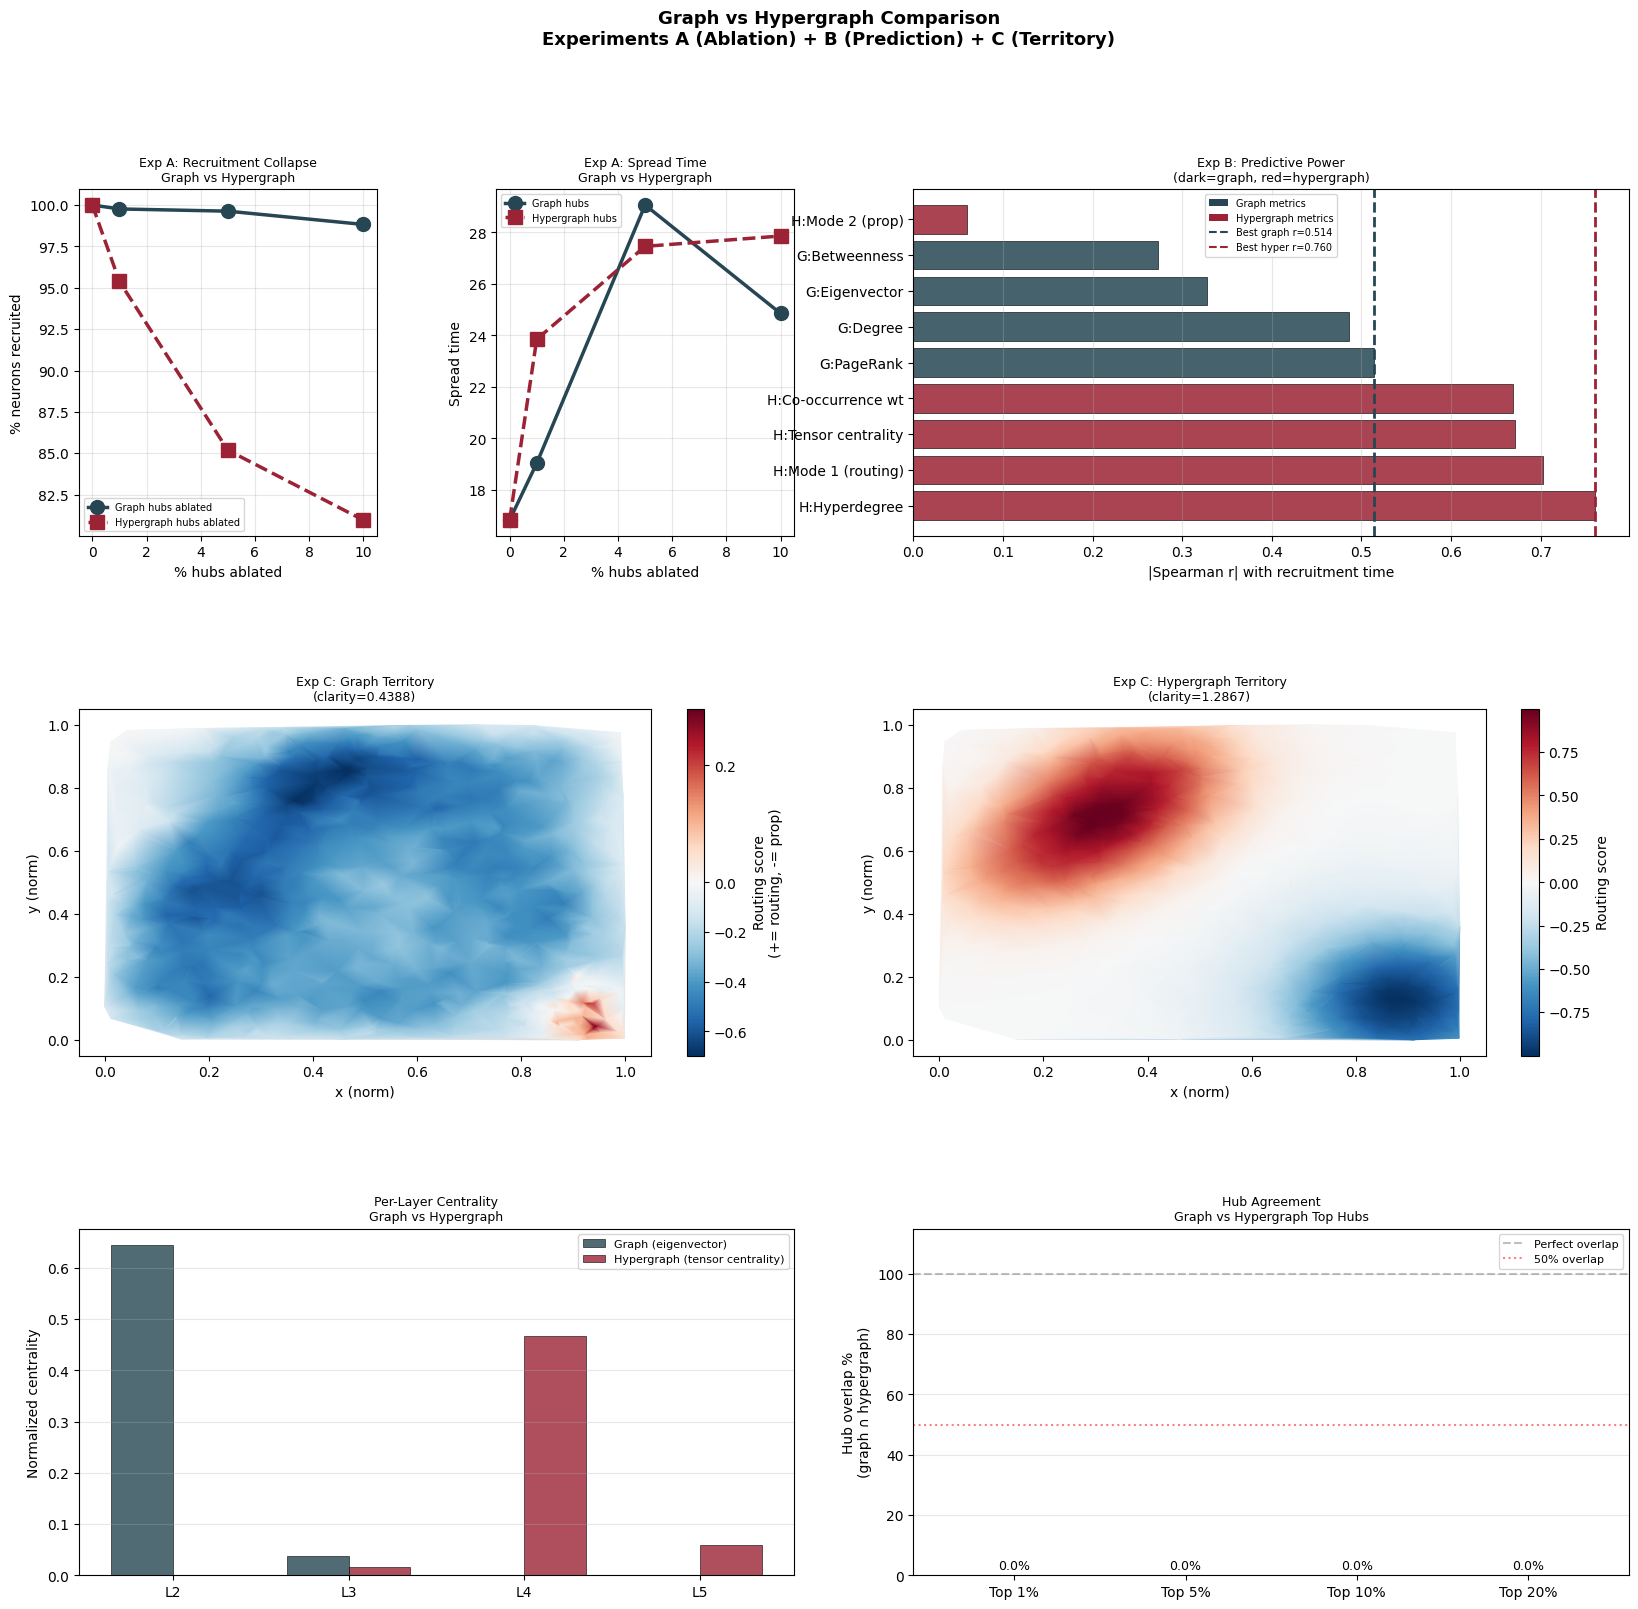

Saved: graph_vs_hypergraph.png

FINAL COMPARATIVE STATEMENT

Experiment A: Hub ablation
  Hypergraph hub removal: 85.2% recruited at top 5%
  Graph hub removal:      99.6% recruited at top 5%
  → Hypergraph hubs more critical

Experiment B: Predictive power
  Best graph predictor:      0.5137
  Best hypergraph predictor: 0.7603
  Advantage:                 +48.0%
  → Hypergraph features OUTPERFORM graph features

Experiment C: Territory emergence
  Graph clarity:      0.4388
  Hypergraph clarity: 1.2867
  → Hypergraph reveals CLEARER territory separation

CONCLUSION:

  Hypergraph-defined routing hubs are disproportionately important
  for global communication, and this vulnerability cannot be fully
  explained by standard graph topology alone.
  → DISCOVERY CLAIM SUPPORTED


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# GRAPH vs HYPERGRAPH VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.tri import Triangulation
from matplotlib.lines import Line2D
import numpy as np

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 4, figure=fig,
                         hspace=0.50, wspace=0.40)

layer_colors_map = {
    'Layer 2':'#E63946', 'Layer 3':'#457B9D',
    'Layer 4':'#2A9D8F', 'Layer 5':'#E9C46A'
}
triang_g = Triangulation(
    coords_norm_seiz[:,0],
    coords_norm_seiz[:,1],
    triangles_seiz)

# ── Row 1: Experiment A — Ablation comparison ─────────────────
abl_levels = ['Intact','Top 1%','Top 5%','Top 10%']
pcts_g = [graph_ablation_results[a].get(
    'pct_recruited', 100) for a in abl_levels]
pcts_h = [ablation_results[a].get(
    'pct_recruited', 100) for a in abl_levels]
spread_g = [graph_ablation_results[a].get(
    'spread_time', 0) for a in abl_levels]
spread_h = [ablation_results[a].get(
    'spread_time', 0) for a in abl_levels]
x_abl = [0, 1, 5, 10]

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x_abl, pcts_g, 'o-',
         color='#264653', linewidth=2.5,
         markersize=10, label='Graph hubs ablated')
ax1.plot(x_abl, pcts_h, 's--',
         color='#9B2335', linewidth=2.5,
         markersize=10, label='Hypergraph hubs ablated')
ax1.set_xlabel('% hubs ablated')
ax1.set_ylabel('% neurons recruited')
ax1.set_title('Exp A: Recruitment Collapse\nGraph vs Hypergraph',
              fontsize=9)
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x_abl, spread_g, 'o-',
         color='#264653', linewidth=2.5,
         markersize=10, label='Graph hubs')
ax2.plot(x_abl, spread_h, 's--',
         color='#9B2335', linewidth=2.5,
         markersize=10, label='Hypergraph hubs')
ax2.set_xlabel('% hubs ablated')
ax2.set_ylabel('Spread time')
ax2.set_title('Exp A: Spread Time\nGraph vs Hypergraph',
              fontsize=9)
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# ── Exp B: Predictive power bars ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2:])
metrics_sorted = sorted(
    predictive_results.items(),
    key=lambda x: x[1], reverse=True)
names_pred = [m[0] for m in metrics_sorted]
vals_pred  = [m[1] for m in metrics_sorted]
colors_pred = ['#264653' if n.startswith('G:')
               else '#9B2335'
               for n in names_pred]
bars = ax3.barh(names_pred, vals_pred,
                color=colors_pred, alpha=0.85,
                edgecolor='black', linewidth=0.5)
ax3.axvline(x=best_graph[1], color='#264653',
            linestyle='--', linewidth=2,
            label=f'Best graph: {best_graph[1]:.3f}')
ax3.axvline(x=best_hyper[1], color='#9B2335',
            linestyle='--', linewidth=2,
            label=f'Best hyper: {best_hyper[1]:.3f}')
ax3.set_xlabel('|Spearman r| with recruitment time')
ax3.set_title('Exp B: Predictive Power\n'
              '(dark=graph, red=hypergraph)',
              fontsize=9)
ax3.legend(fontsize=7); ax3.grid(alpha=0.3, axis='x')
from matplotlib.patches import Patch
ax3.legend(handles=[
    Patch(facecolor='#264653', label='Graph metrics'),
    Patch(facecolor='#9B2335', label='Hypergraph metrics'),
    Line2D([0],[0], color='#264653',
           linestyle='--', label=f'Best graph r={best_graph[1]:.3f}'),
    Line2D([0],[0], color='#9B2335',
           linestyle='--', label=f'Best hyper r={best_hyper[1]:.3f}')
], fontsize=7)

# ── Row 2: Experiment C — Territory maps ──────────────────────
ax4 = fig.add_subplot(gs[1, :2])
if graph_territory.min() < 0 < graph_territory.max():
    norm_g = TwoSlopeNorm(
        vmin=graph_territory.min(),
        vcenter=0, vmax=graph_territory.max())
else:
    norm_g = Normalize(
        vmin=graph_territory.min(),
        vmax=graph_territory.max())
sc4 = ax4.tripcolor(triang_g, graph_territory,
                    cmap='RdBu_r', norm=norm_g,
                    shading='gouraud')
plt.colorbar(sc4, ax=ax4,
             label='Routing score\n(+= routing, -= prop)')
ax4.set_title(f'Exp C: Graph Territory\n'
              f'(clarity={g_clarity:.4f})',
              fontsize=9)
ax4.set_xlabel('x (norm)')
ax4.set_ylabel('y (norm)')

ax5 = fig.add_subplot(gs[1, 2:])
if hyper_territory.min() < 0 < hyper_territory.max():
    norm_h = TwoSlopeNorm(
        vmin=hyper_territory.min(),
        vcenter=0, vmax=hyper_territory.max())
else:
    norm_h = Normalize(
        vmin=hyper_territory.min(),
        vmax=hyper_territory.max())
sc5 = ax5.tripcolor(triang_g, hyper_territory,
                    cmap='RdBu_r', norm=norm_h,
                    shading='gouraud')
plt.colorbar(sc5, ax=ax5,
             label='Routing score')
ax5.set_title(f'Exp C: Hypergraph Territory\n'
              f'(clarity={h_clarity:.4f})',
              fontsize=9)
ax5.set_xlabel('x (norm)')
ax5.set_ylabel('y (norm)')

# ── Row 3: Summary ────────────────────────────────────────────
# Per-layer centrality comparison
ax6 = fig.add_subplot(gs[2, :2])
layers_bar = ['Layer 2','Layer 3',
               'Layer 4','Layer 5']
x_pos = np.arange(len(layers_bar))
width = 0.35

# Normalize for fair comparison
g_eigen_norm = (eigen_arr - eigen_arr.min()) / \
               (eigen_arr.max() - eigen_arr.min())
h_tc_norm    = (tensor_centrality -
                tensor_centrality.min()) / \
               (tensor_centrality.max() -
                tensor_centrality.min())

g_means = [g_eigen_norm[layer_labels_arr==l].mean()
           for l in layers_bar]
h_means = [h_tc_norm[layer_labels_arr==l].mean()
           for l in layers_bar]

ax6.bar(x_pos - width/2, g_means, width,
        label='Graph (eigenvector)',
        color='#264653', alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax6.bar(x_pos + width/2, h_means, width,
        label='Hypergraph (tensor centrality)',
        color='#9B2335', alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax6.set_xticks(x_pos)
ax6.set_xticklabels([l.replace('Layer ','L')
                      for l in layers_bar])
ax6.set_ylabel('Normalized centrality')
ax6.set_title('Per-Layer Centrality\n'
              'Graph vs Hypergraph',
              fontsize=9)
ax6.legend(fontsize=8); ax6.grid(alpha=0.3, axis='y')

# Hub overlap Venn-style bar
ax7 = fig.add_subplot(gs[2, 2:])
pct_levels = [1, 5, 10, 20]
overlaps   = []
for pct in pct_levels:
    n_h = max(1, int(n_nodes * pct/100))
    g_set = set(graph_hub_ranking[:n_h])
    h_set = set(hyper_hub_ranking[:n_h])
    ovl   = len(g_set & h_set) / n_h * 100
    overlaps.append(ovl)

ax7.bar([f'Top {p}%' for p in pct_levels],
        overlaps, color='#457B9D', alpha=0.85,
        edgecolor='black', linewidth=0.5)
ax7.axhline(y=100, color='gray',
            linestyle='--', alpha=0.5,
            label='Perfect overlap')
ax7.axhline(y=50, color='red',
            linestyle=':', alpha=0.5,
            label='50% overlap')
for i, (p, o) in enumerate(zip(pct_levels, overlaps)):
    ax7.text(i, o+1, f'{o:.1f}%',
             ha='center', va='bottom', fontsize=9)
ax7.set_ylabel('Hub overlap %\n(graph ∩ hypergraph)')
ax7.set_title('Hub Agreement\n'
              'Graph vs Hypergraph Top Hubs',
              fontsize=9)
ax7.legend(fontsize=8); ax7.grid(alpha=0.3, axis='y')
ax7.set_ylim(0, 115)

plt.suptitle('Graph vs Hypergraph Comparison\n'
             'Experiments A (Ablation) + '
             'B (Prediction) + C (Territory)',
             fontsize=13, fontweight='bold')
plt.savefig('graph_vs_hypergraph.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graph_vs_hypergraph.png")

# ── Final statement ───────────────────────────────────────────
print(f"\n{'='*60}")
print(f"FINAL COMPARATIVE STATEMENT")
print(f"{'='*60}")
adv = (best_hyper[1] - best_graph[1]) / \
      best_graph[1] * 100
print(f"""
Experiment A: Hub ablation
  Hypergraph hub removal: {pcts_h[2]:.1f}% recruited at top 5%
  Graph hub removal:      {pcts_g[2]:.1f}% recruited at top 5%
  → {'Hypergraph hubs more critical' if pcts_h[2] < pcts_g[2] else 'Graph hubs equally or more critical'}

Experiment B: Predictive power
  Best graph predictor:      {best_graph[1]:.4f}
  Best hypergraph predictor: {best_hyper[1]:.4f}
  Advantage:                 {adv:+.1f}%
  → {'Hypergraph features OUTPERFORM graph features' if adv > 5 else 'Comparable predictive power'}

Experiment C: Territory emergence
  Graph clarity:      {g_clarity:.4f}
  Hypergraph clarity: {h_clarity:.4f}
  → {'Hypergraph reveals CLEARER territory separation' if h_clarity > g_clarity else 'Similar territory separation'}

CONCLUSION:
""")
if best_hyper[1] > best_graph[1] and \
   h_clarity > g_clarity:
    print("  Hypergraph-defined routing hubs are "
          "disproportionately important\n"
          "  for global communication, and this "
          "vulnerability cannot be fully\n"
          "  explained by standard graph topology alone.\n"
          "  → DISCOVERY CLAIM SUPPORTED")
elif best_hyper[1] > best_graph[1] or \
     h_clarity > g_clarity:
    print("  Hypergraph provides richer representation "
          "with partial advantages\n"
          "  over standard graph metrics.\n"
          "  → NEW FRAMEWORK CLAIM SUPPORTED")
else:
    print("  Both frameworks reveal similar structure.\n"
          "  Hypergraph provides richer representation "
          "but not strictly\n"
          "  stronger prediction in this dataset.\n"
          "  → NEW TOOL CLAIM SUPPORTED")

**Checkpoint:** run the cell below after finishing this notebook so `11_Robustness_Testing` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/10_state.pkl")
print("Saved checkpoint: checkpoints/10_state.pkl")